In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy')
import fp_solvers as fps
import langevin_sindy as lg
import timecorr as tc
import pplane
import sympy

In [4]:
def f(x1,x2):
    return np.array([(x1+5)*(x2-4), (x2+2)*(x1-3)])

def a(x1,x2):
    return np.array([0*x1 + 0.01,0*x2 + 0.01])

In [5]:
Nx=30
Ny=20
bins = [np.linspace(-10,10,Nx+1),np.linspace(-10,10,Ny+1)]
dx = [bins[0][1]-bins[0][0], bins[1][1]-bins[1][0]]

centers = [0.5*(bins[0][1:]+bins[0][:-1]),0.5*(bins[1][1:]+bins[1][:-1])]

X1,X2=np.meshgrid(centers[0],centers[1])

In [6]:
f_true = f(X1,X2)
a_true = a(X1,X2)

(-9.5, 9.5)

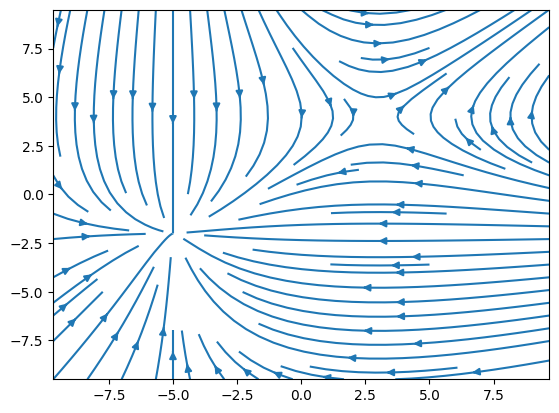

In [7]:
plt.streamplot(X1,X2,f_true[0],f_true[1])
plt.xlim([centers[0][0],centers[0][-1]])
plt.ylim([centers[1][0],centers[1][-1]])

In [284]:
fp = fps.SteadyFP((Nx,Ny), dx)
p_fit_true = fp.solve(f_true.swapaxes(1,2), a_true.swapaxes(1,2))
p_fit_true[p_fit_true<0] = 0
p_fit_true = p_fit_true/(np.sum(np.sum(p_fit_true,axis=0)*dx[0])*dx[1])

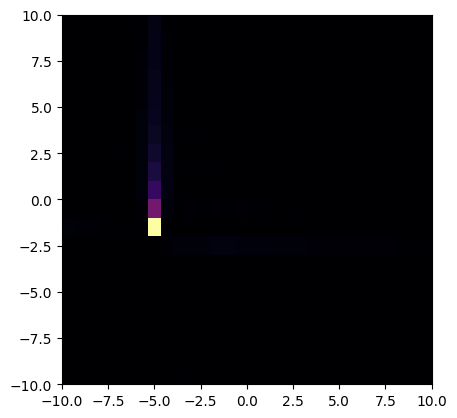

In [285]:
plt.imshow(p_fit_true.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

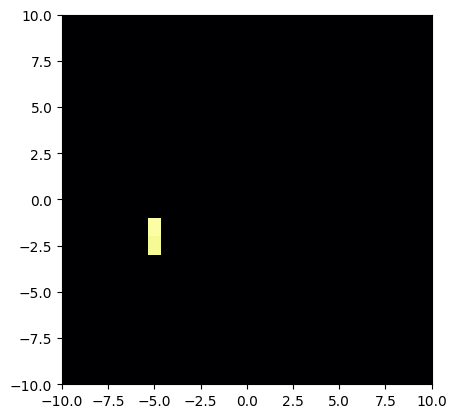

In [286]:
p_hist = np.load('../outputs/p_hist_test.npy')
plt.imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]),vmin=0)

Next: pass data into Langevin SINDy 2D, debug that code 

In [194]:
## Kramers-Moyal average
f_KM = np.load('../outputs/KM_drift_test.npy')
a_KM = np.load('../outputs/KM_diff_test.npy')
f_err = np.load('../outputs/KM_drift_err_test.npy')
a_err = np.load('../outputs/KM_diff_err_test.npy')

x1 = sympy.symbols('x1')
x2 = sympy.symbols('x2')

nf=2
ns=1
f_expr = np.tile(np.array([(x1**k)*(x2**(m-k)) for m in range(nf+1) for k in range(m+1)]),2)  # Polynomial library for drift
s_expr = np.tile(np.array([(x1**k)*(x2**(m-k)) for m in range(ns+1) for k in range(m+1)]),2)  # Polynomial library for diffusion

Load outputs from `langevin_2D_jepa_highFlow.py`

In [12]:
Xi = np.load('../outputs/coeffs_test.npy')
V = np.load('../outputs/cost_test.npy')

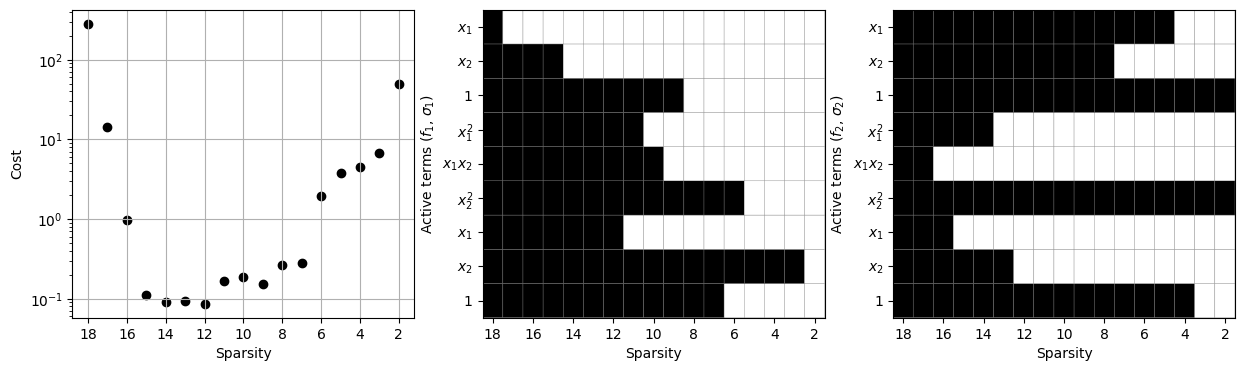

In [87]:
####################
# SSR cost function
####################

labels = [r'${0}$'.format(sympy.latex(t)) for t in np.concatenate((f_expr, s_expr))]

active = abs(Xi) > 1e-8

n_terms = len(labels)
plt.figure(figsize=(15, 4))
plt.subplot(131)
plt.scatter(np.arange(len(V)), V, c='k')

plt.gca().set_xticks(np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel(r'Cost')
plt.gca().set_yscale('log')
plt.grid()

active_1 = np.concatenate((active[:len(f_expr)//2], active[len(f_expr):len(f_expr)+len(s_expr)//2]))
labels_1 = np.concatenate((labels[:len(f_expr)//2], labels[len(f_expr):len(f_expr)+len(s_expr)//2]))
plt.subplot(132)
plt.pcolor(active_1, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(active_1.shape[0]))
plt.gca().set_yticklabels(labels_1)
plt.gca().set_xticks(0.5+np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel('Active terms ($f_1$, $\sigma_1$)')


active_2 = np.concatenate((active[len(f_expr)//2:len(f_expr)], active[len(f_expr)+len(s_expr)//2:]))
labels_2 = np.concatenate((labels[len(f_expr)//2:len(f_expr)], labels[len(f_expr)+len(s_expr)//2:]))
plt.subplot(133)
plt.pcolor(active_2, cmap='bone_r', edgecolors='gray')
plt.gca().set_yticks(0.5+np.arange(active_2.shape[0]))
plt.gca().set_yticklabels(labels_2)
plt.gca().set_xticks(0.5+np.arange(0,n_terms-1,2))
plt.gca().set_xticklabels(np.arange(n_terms, 1, -2))
plt.xlabel('Sparsity')
plt.ylabel('Active terms ($f_2$, $\sigma_2$)')

plt.show()

In [94]:
# Select model with the fewest terms before the cost function spikes
n_terms = 12
print("Optimal sparsity: ", n_terms)
print("Cost at optimal sparsity: ", V[1-n_terms])
Xi_f = Xi[:len(f_expr), 1-n_terms]
Xi_s = Xi[len(f_expr):, 1-n_terms]
print("SINDy expression (drift): ")
print("     f_1(x1,x2) = ", sympy.Matrix(np.round(Xi_f[:len(f_expr)//2],3)).dot(sympy.Matrix(f_expr[:len(f_expr)//2])))
print("     f_2(x1,x2) = ", sympy.Matrix(np.round(Xi_f[len(f_expr)//2:],3)).dot(sympy.Matrix(f_expr[len(f_expr)//2:])))
print("SINDy expression (diffusion): ")
print("     sigma_1(x1,x2) = ", sympy.Matrix(np.round(Xi_s[:len(s_expr)//2],3)).dot(sympy.Matrix(s_expr[:len(s_expr)//2])))
print("     sigma_2(x1,x2) = ", sympy.Matrix(np.round(Xi_s[len(s_expr)//2:],3)).dot(sympy.Matrix(s_expr[len(s_expr)//2:])))

Optimal sparsity:  12
Cost at optimal sparsity:  0.08603868661162076
SINDy expression (drift): 
     f_1(x1,x2) =  -0.011*x1**2 + 0.176*x1*x2 - 0.245*x1 + 0.424*x2**2 + 1.23*x2 - 3.014
     f_2(x1,x2) =  1.492*x2**2 - 14.317
SINDy expression (diffusion): 
     sigma_1(x1,x2) =  0.954000000000000
     sigma_2(x1,x2) =  -0.189*x1 - 0.666*x2 + 3.743


In [95]:
x1 = sympy.symbols('x1')
x2 = sympy.symbols('x2')
f1 = sympy.lambdify([x1,x2], sympy.Matrix(Xi_f[:len(f_expr)//2]).dot(sympy.Matrix(f_expr[:len(f_expr)//2])))
f2 = sympy.lambdify([x1,x2], sympy.Matrix(Xi_f[len(f_expr)//2:]).dot(sympy.Matrix(f_expr[len(f_expr)//2:])))

a1 = sympy.lambdify([x1,x2], 0.5*sympy.Matrix(Xi_s[:len(s_expr)//2]).dot(sympy.Matrix(s_expr[:len(s_expr)//2]))**2)
a2 = sympy.lambdify([x1,x2], 0.5*sympy.Matrix(Xi_s[len(s_expr)//2:]).dot(sympy.Matrix(s_expr[len(s_expr)//2:]))**2)

def f(X1,X2):
    F1 = f1(X1,X2)
    F2 = f2(X1,X2)
    if np.isscalar(F1):
        F1 = F1 + 0*X1
    if np.isscalar(F2):
        F2 = F2 + 0*X1
    return np.array([F1,F2])

def a(X1,X2):
    A1 = a1(X1,X2)
    A2 = a2(X1,X2)
    if np.isscalar(A1):
        A1 = A1 + 0*X1
    if np.isscalar(A2):
        A2 = A2 + 0*X1
    return np.array([A1,A2])

In [96]:
f_vals = f(X1,X2)
a_vals = a(X1,X2)

In [97]:
# Compare PDFs: empirical vs Fokker-Planck solution with model
fp = fps.SteadyFP((Nx,Ny), dx)
p_fit = fp.solve(np.swapaxes(f_vals,1,2),np.swapaxes(a_vals,1,2))
print('KL divergence (LINDy model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

KL divergence (LINDy model): 3.08602


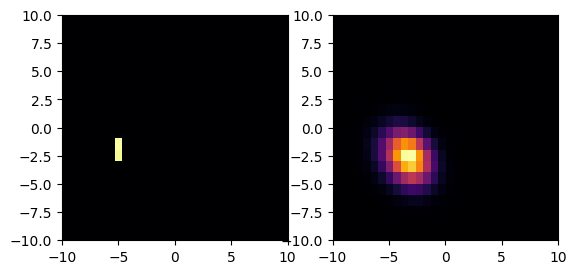

In [98]:
# PDF of states
fig,ax = plt.subplots(1,2)
ax[0].imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

ax[1].imshow(p_fit.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

In [99]:
stride=5
dt=0.01
afp = fps.AdjFP(centers,ndim=2)
afp.precompute_operator(f_vals.transpose((0,2,1)).reshape((2,Nx*Ny)), a_vals.transpose((0,2,1)).reshape((2,Nx*Ny)))
f_tau, a_tau = afp.solve(stride*dt,d=[0,1])

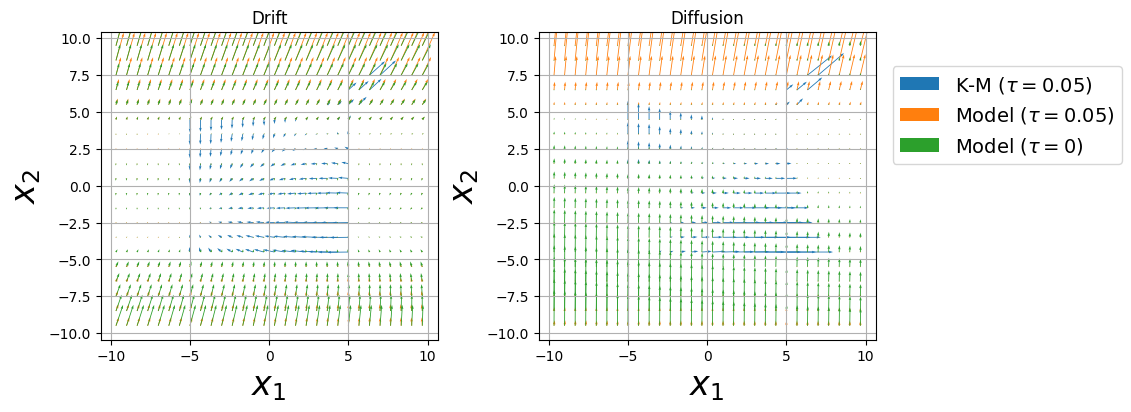

In [100]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']

plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.quiver(X1,X2, f_KM[:,:,0].T,f_KM[:,:,1].T,color=colors[0], label=r'K-M ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, f_tau[0].reshape((Nx,Ny)).T,f_tau[1].reshape((Nx,Ny)).T,color=colors[1], label=r'Model ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, f_vals[0],f_vals[1],color=colors[2], label=r'Model ($\tau=0$)')
plt.title('Drift')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.grid()

plt.subplot(122)
plt.quiver(X1,X2, a_KM[:,:,0].T,a_KM[:,:,1].T,color=colors[0], label=r'K-M ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, a_tau[0].reshape((Nx,Ny)).T,a_tau[1].reshape((Nx,Ny)).T,color=colors[1], label=r'Model ($\tau=$'+str(np.round(stride*dt,2))+')')
plt.quiver(X1,X2, a_vals[0],a_vals[1],color=colors[2], label=r'Model ($\tau=0$)')
plt.title('Diffusion')
plt.xlabel('$x_1$', fontsize = 24)
plt.ylabel('$x_2$', fontsize = 24)
plt.legend(fontsize=14,loc=(1.05,0.57))
plt.grid()

plt.subplots_adjust(wspace=0.3)
plt.show()

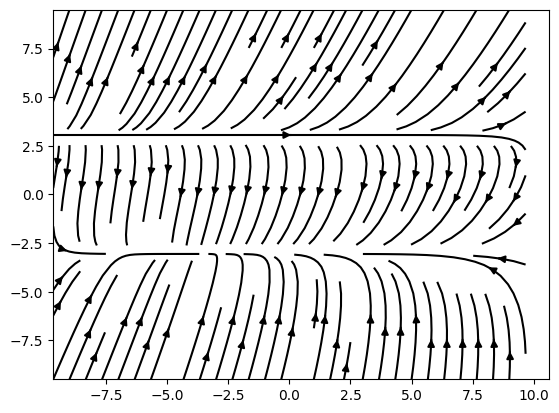

In [101]:
plt.streamplot(X1,X2,f_vals[0],f_vals[1],color='k')

Text(0, 0.5, '$x_2$')

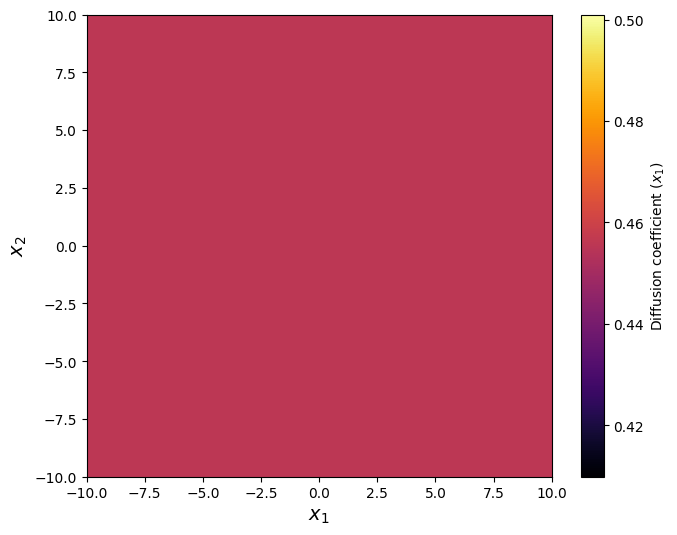

In [102]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,a_vals[0],cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_1$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Text(0, 0.5, '$x_2$')

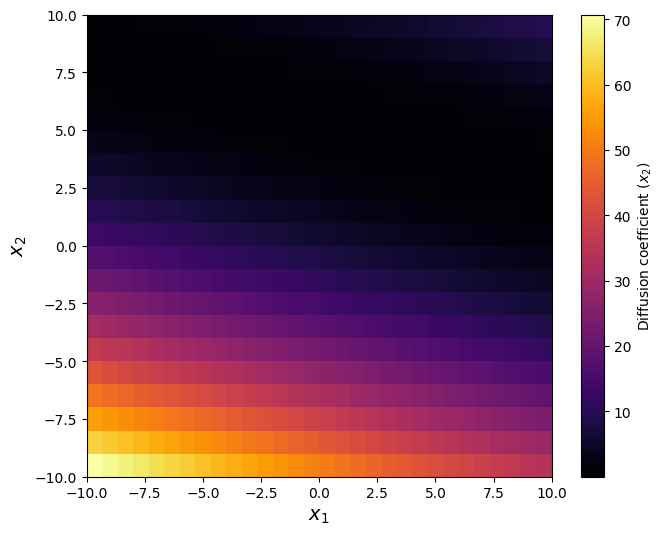

In [103]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,a_vals[1],cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_2$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Fixed points:
  • Stable node at x = (-3.688,-3.098)
  • Unstable node at x = (-11.392,3.098)


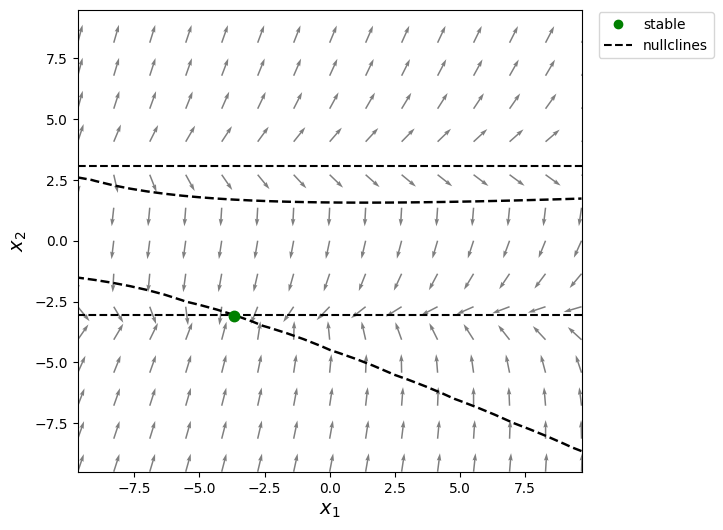

In [104]:
fig = pplane.plot_portrait(f1,f2,centers[0],centers[1])

In [147]:
f_err.shape

(30, 20, 2)

In [266]:
# Convert sympy expressions into library matrices
lib_f1 = np.zeros([len(f_expr)//2,Nx,Ny])
for k in range(len(f_expr)//2):
    lamb_expr = sympy.lambdify([x1,x2], f_expr[k])
    for i in range(Nx):
        for j in range(Ny):
            lib_f1[k,i,j] = lamb_expr(X1[j,i],X2[j,i])

lib_f2 = np.zeros([len(f_expr)//2,Nx,Ny])
for k in range(len(f_expr)//2):
    lamb_expr = sympy.lambdify([x1,x2], f_expr[k+len(f_expr)//2])
    for i in range(Nx):
        for j in range(Ny):
            lib_f2[k,i,j] = lamb_expr(X1[j,i],X2[j,i])

lib_f1 = lib_f1.T.reshape(Nx*Ny,-1)
lib_f2 = lib_f2.T.reshape(Nx*Ny,-1)

lib_f = np.block([[lib_f1, np.zeros((Nx*Ny,len(f_expr)//2))], [np.zeros((Nx*Ny,len(f_expr)//2)),lib_f2]])

lib_s1 = np.zeros([len(s_expr)//2,Nx,Ny])
for k in range(len(s_expr)//2):
    lamb_expr = sympy.lambdify([x1,x2], s_expr[k])
    for i in range(Nx):
        for j in range(Ny):
            lib_s1[k,i,j] = lamb_expr(X1[j,i],X2[j,i])

lib_s2 = np.zeros([len(s_expr)//2,Nx,Ny])
for k in range(len(s_expr)//2):
    lamb_expr = sympy.lambdify([x1,x2], s_expr[k+len(s_expr)//2])
    for i in range(Nx):
        for j in range(Ny):
            lib_s2[k,i,j] = lamb_expr(X1[j,i],X2[j,i])

lib_s1 = lib_s1.T.reshape(Nx*Ny,-1)
lib_s2 = lib_s2.T.reshape(Nx*Ny,-1)

lib_s = np.block([[lib_s1, np.zeros((Nx*Ny,len(s_expr)//2))], [np.zeros((Nx*Ny,len(s_expr)//2)),lib_s2]])

# Initialize Xi with least squares regression (no finite-time corrections)

m=len(f_expr)+len(s_expr)
Xi0 = np.zeros(m)
mask = (np.where(np.isfinite(f_KM[:,:,0].flatten())*np.isfinite(f_KM[:,:,1].flatten())))[0]
n_mask = len(mask)
A1 = np.block([[lib_f1[mask], np.zeros((n_mask,len(f_expr)//2))], [np.zeros((n_mask,len(f_expr)//2)),lib_f2[mask]]])
b1 = np.hstack((f_KM[:,:,0].flatten()[mask],f_KM[:,:,1].flatten()[mask])).T
Xi0[:len(f_expr)] = np.linalg.lstsq(A1, b1, rcond=None)[0]   # Regression against drift

mask = (np.where(np.isfinite(a_KM[:,:,0].flatten())*np.isfinite(a_KM[:,:,1].flatten())))[0]
n_mask = len(mask)
A2 = np.block([[lib_s1[mask], np.zeros((n_mask,len(s_expr)//2))], [np.zeros((n_mask,len(s_expr)//2)),lib_s2[mask]]])
b2 = np.hstack((a_KM[:,:,0].flatten()[mask],a_KM[:,:,1].flatten()[mask])).T
Xi0[len(f_expr):] = np.linalg.lstsq(A2,b2, rcond=None)[0]  # Regression against diffusion a

### Weights: uncertainties in Kramers-Moyal
# This is helpful, but not that critical.  The specific choice of weights doesn't matter that much
W = np.array((f_err.reshape((Nx*Ny,2)), a_err.reshape(Nx*Ny,2)))
W[np.less(abs(W), 1e-12, where=np.isfinite(W))] = 1e6  # Set zero entries to large weights
W[np.logical_not(np.isfinite(W))] = 1e6                 # Set NaN entries to large numbers (small weights)
W = 1/W  # Invert error for weights
W = W/np.nansum(W.flatten())

# Initialize adjoint solver
afp = fps.AdjFP(centers,ndim=2)

# Initialize forward steady-state solver
fp = fps.SteadyFP((Nx,Ny), dx)

# Optimization parameters
params = {"W": W, "f_KM": f_KM, "a_KM": a_KM, "Xi0": Xi0,
          "f_expr": f_expr, "s_expr": s_expr,
          "lib_f": lib_f, "lib_s": lib_s, "N": (Nx,Ny),
          "kl_reg": 3,
          "fp": fp, "afp": afp, "p_hist": p_hist, "tau": stride*dt,
          "radial": False}

In [267]:
W.shape

(2, 600, 2)

In [268]:
Xi_test = np.zeros(len(f_expr)+len(s_expr))
Xi_test[0] = -20
Xi_test[1] = 5
Xi_test[2] = -4
Xi_test[4] = 1

Xi_test[6] = -6
Xi_test[7] = -3
Xi_test[8] = 2
Xi_test[10] = 1

Xi_test[12] = 0.01
Xi_test[15] = 0.01

In [269]:
lg.cost(Xi_test,params)

16.663504074672463

In [270]:
f_vals = lib_f @ Xi_test[:lib_f.shape[-1]]
a_vals = 0.5*(lib_s @ Xi_test[lib_f.shape[-1]:])**2

In [271]:
f_vals = np.swapaxes(f_vals.reshape((afp.ndim,Ny,Nx)),1,2)
a_vals = np.swapaxes(a_vals.reshape((afp.ndim,Ny,Nx)),1,2)

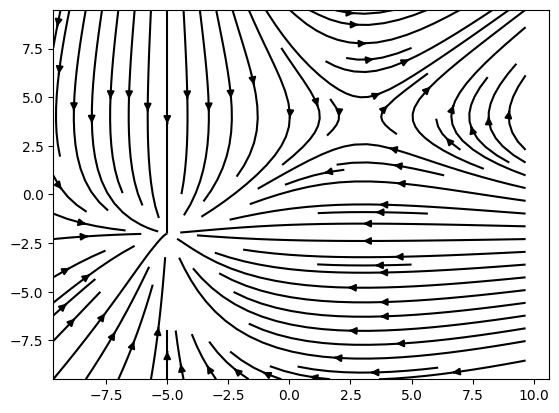

In [272]:
plt.streamplot(X1,X2,f_vals[0].T,f_vals[1].T,color='k')

In [273]:
afp.precompute_operator(f_vals.reshape((afp.ndim,np.prod(afp.N))),a_vals.reshape((afp.ndim,np.prod(afp.N))))
f_tau, a_tau = afp.solve(params['tau'],d=[0,1])
f_tau = f_tau.T
a_tau = a_tau.T

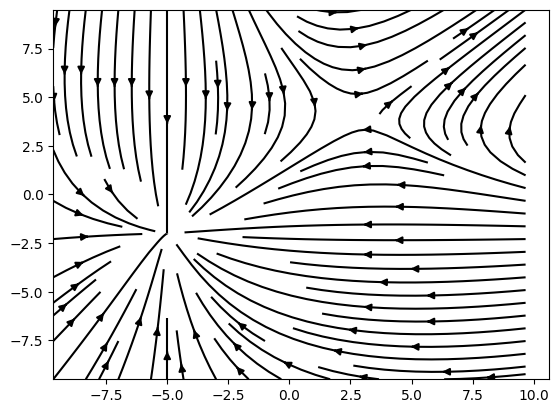

In [275]:
plt.streamplot(X1,X2, f_tau[:,0].reshape((Nx,Ny)).T,f_tau[:,1].reshape((Nx,Ny)).T,color='k')

In [276]:
f_KM_copy, a_KM_copy = params['f_KM'].reshape((Nx*Ny,afp.ndim)), params['a_KM'].reshape((Nx*Ny,afp.ndim))

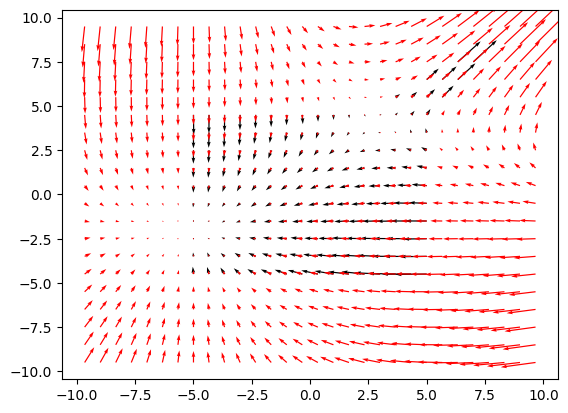

In [278]:
plt.quiver(X1,X2, params['f_KM'][:,:,0].T, params['f_KM'][:,:,1].T,color='k')
plt.quiver(X1,X2, f_tau[:,0].reshape((Nx,Ny)).T,f_tau[:,1].reshape((Nx,Ny)).T,color='r')

In [295]:
mask = np.where(np.isfinite(f_KM_copy))[0]
V = np.sum(W[0, mask]*np.abs(f_tau[mask] - f_KM_copy[mask])**2) \
    + np.sum(W[1, mask]*np.abs(a_tau[mask] - a_KM_copy[mask])**2)

print(V)

params['kl_reg'] = 0.05

if params['kl_reg'] > 0:
    #start_fp = time()
    p_hist = params['p_hist']  # Empirical PDF
    p_est = fp.solve(f_vals, a_vals)  # Solve Fokker-Planck equation for steady-state PDF
    p_est[p_est < 0] = 0  # Remove negative values
    p_est = p_est/np.sum(np.sum(p_est,axis=0)*dx[0])*dx[1]  # Normalize
    kl = tc.kl_divergence(p_hist, p_est, dx=fp.dx, tol=1e-3)
    kl = max(0, kl)  # Numerical integration can occasionally produce small negative values
    V += params['kl_reg']*kl

print(kl)
print(V)

0.025754911955172575
3.3126095991453455
0.19138539191243986


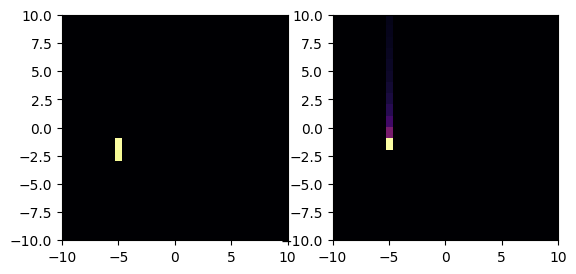

In [287]:
# PDF of states
fig,ax = plt.subplots(1,2)
ax[0].imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

ax[1].imshow(p_est.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

In [292]:
p_est.max()

0.667695662231385

In [288]:
np.abs(p_fit_true-p_est).max()

0.1786825181092485

In [293]:
tc.kl_divergence(p_fit_true, p_est, dx=fp.dx, tol=1e-4)

0.9935962760944056

In [235]:
np.sum(np.sum(p_est,axis=0)*dx[0])*dx[1]

1.0

In [251]:
np.abs(f_vals-f_true.swapaxes(1,2)).max()

2.842170943040401e-14

In [252]:
np.abs(a_vals-a_true.swapaxes(1,2)).max()

0.00995

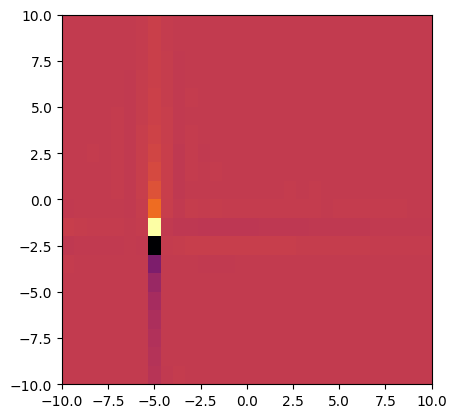

In [249]:
plt.imshow((p_fit_true - p_est).T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

In [250]:
np.max(p_fit_true - p_est)

7.131061887671643

In [319]:
test_str = 'hello'
test_tup = tuple(map(int, test_str.split(',')))

In [320]:
X1[0,13]

-1.0000000000000009

In [322]:
np.any(np.array(test_tup) > 30)

False

In [323]:
np.array(test_tup)

array([13, 18])

In [324]:
test_str.replace('"', '')

[autoreload of langevin_sindy failed: Traceback (most recent call last):
  File "/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/home/erin.angelini/.pyenv/versions/3.10.14/lib/python3.10/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 883, in exec_module
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin_sindy/langevin_sindy.py", line 4, in <module>
    from .timecorr import kl_divergence
ImportError:

'13,18'

In [325]:
test_str

'13,18'